# 03 — EDA: Cancellation Analysis
**Hotel Booking Demand Dataset**

This notebook explores cancellation patterns in the cleaned dataset.
We examine the overall cancellation rate and compare behaviour across hotel types
to surface actionable business insights.

**Key questions:**
- What proportion of all bookings are cancelled?
- Does cancellation behaviour differ between City Hotels and Resort Hotels?
- What are the revenue and operational implications?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

PALETTE = {"Not Cancelled": "#2ca02c", "Cancelled": "#d62728",
           "City Hotel": "#1f77b4", "Resort Hotel": "#ff7f0e"}


In [2]:
df = pd.read_csv("../data/cleaned/hotel_cleaned.csv",
                 parse_dates=["reservation_status_date", "arrival_date"])

print(f"Dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Hotels  : {df['hotel'].unique().tolist()}")
print(f"Nulls   : {df.isnull().sum().sum()}")


Dataset: 85,598 rows × 36 columns
Hotels  : ['Resort Hotel', 'City Hotel']
Nulls   : 0


---
## 1 — Overall Cancellation Rate

In [3]:
n_total      = len(df)
n_cancelled  = df["is_canceled"].sum()
n_active     = n_total - n_cancelled
cancel_rate  = df["is_canceled"].mean() * 100

print("=" * 45)
print(f"  Total bookings      : {n_total:>8,}")
print(f"  Cancelled           : {n_cancelled:>8,}  ({cancel_rate:.2f}%)")
print(f"  Not cancelled       : {n_active:>8,}  ({100 - cancel_rate:.2f}%)")
print("=" * 45)


  Total bookings      :   85,598
  Cancelled           :   23,839  (27.85%)
  Not cancelled       :   61,759  (72.15%)


### Pie Chart — Cancelled vs Not Cancelled

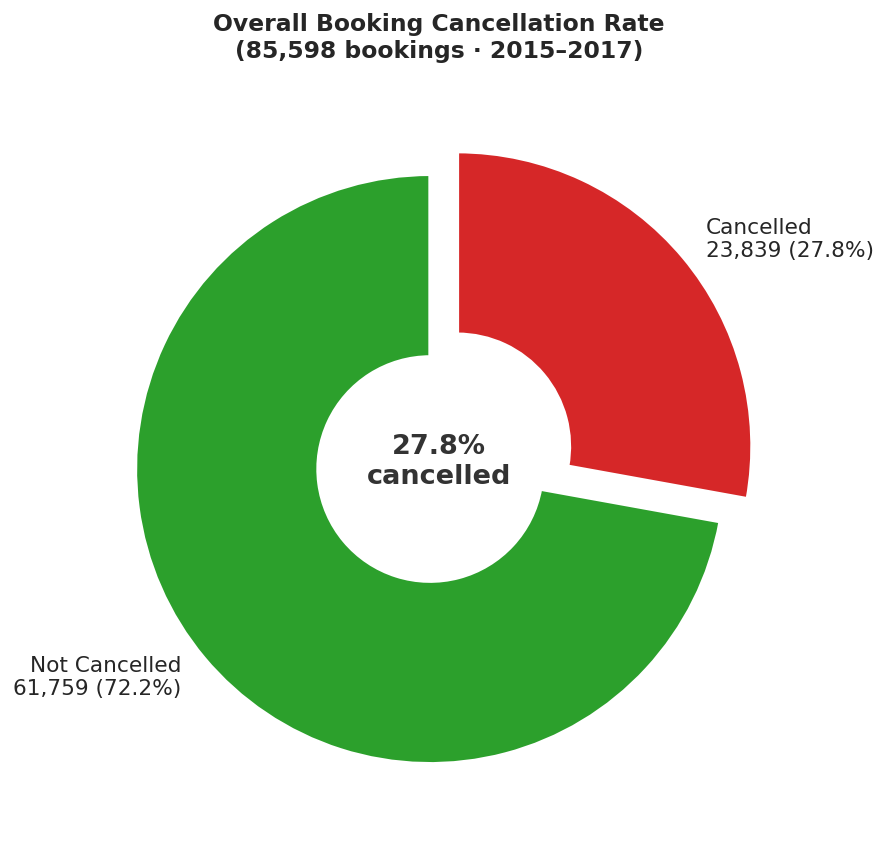

Saved → visuals/cancellation_overall_pie.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 7))

sizes  = [n_active, n_cancelled]
labels = [f"Not Cancelled\n{n_active:,} ({100 - cancel_rate:.1f}%)",
          f"Cancelled\n{n_cancelled:,} ({cancel_rate:.1f}%)"]
colors  = [PALETTE["Not Cancelled"], PALETTE["Cancelled"]]
explode = (0.04, 0.08)

wedges, texts = ax.pie(
    sizes, labels=labels, colors=colors, explode=explode,
    startangle=90,
    wedgeprops=dict(width=0.62, edgecolor="white", linewidth=2),
    textprops=dict(fontsize=12),
)

ax.set_title("Overall Booking Cancellation Rate\n(85,598 bookings · 2015–2017)",
             fontsize=13, fontweight="bold", pad=20)

# Centre annotation
ax.text(0, 0, f"{cancel_rate:.1f}%\ncancelled",
        ha="center", va="center", fontsize=15, fontweight="bold", color="#333333")

plt.tight_layout()
plt.savefig("../visuals/cancellation_overall_pie.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/cancellation_overall_pie.png")


---
## 2 — Cancellation by Hotel Type

In [5]:
# Build summary table
hotel_stats = (
    df.groupby("hotel")["is_canceled"]
      .agg(
          Total="count",
          Cancelled="sum",
          Not_Cancelled=lambda x: (x == 0).sum(),
      )
      .assign(Cancellation_Rate=lambda d: (d["Cancelled"] / d["Total"] * 100).round(2))
      .sort_values("Cancellation_Rate", ascending=False)
)

print("Cancellation statistics by hotel type:")
print()
print(hotel_stats.to_string())


Cancellation statistics by hotel type:

              Total  Cancelled  Not_Cancelled  Cancellation_Rate
hotel                                                           
City Hotel    52351      15939          36412              30.45
Resort Hotel  33247       7900          25347              23.76


### Bar Chart — Cancellation Counts by Hotel Type

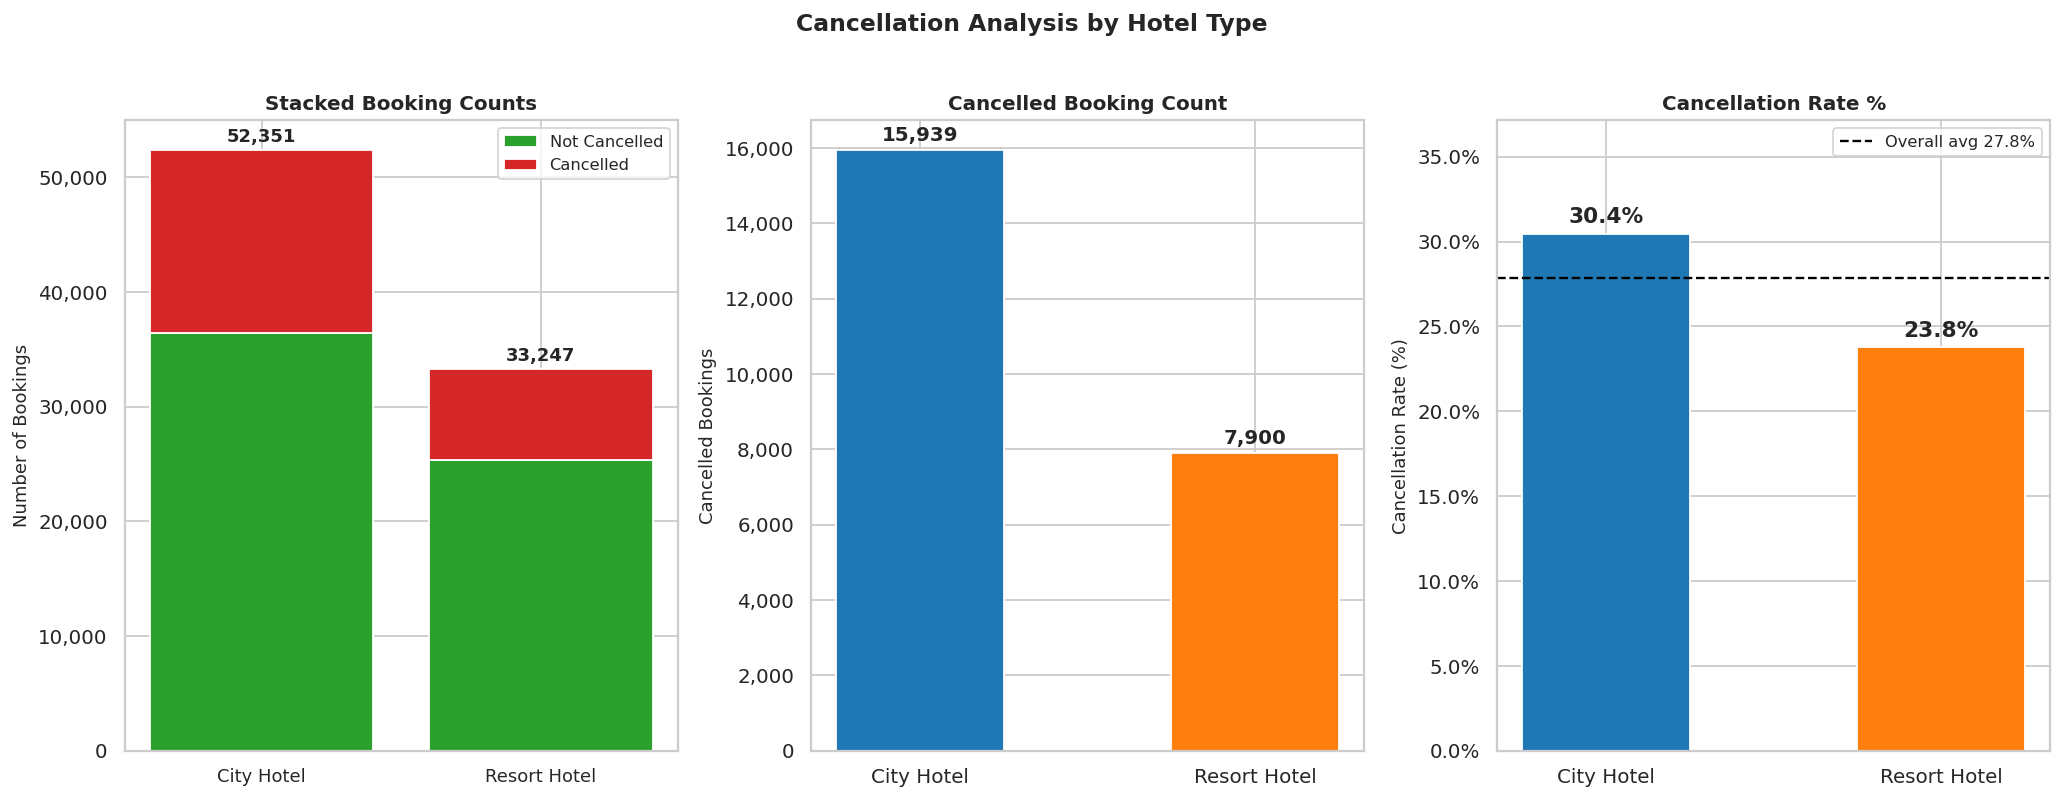

Saved → visuals/cancellation_by_hotel_type.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Cancellation Analysis by Hotel Type",
             fontsize=13, fontweight="bold", y=1.02)

hotels     = hotel_stats.index.tolist()
bar_colors = [PALETTE.get(h, "#999") for h in hotels]

# ── Plot 1: Stacked absolute counts ─────────────────────────────────────────
x    = range(len(hotels))
bars_nc = axes[0].bar(x, hotel_stats["Not_Cancelled"],
                      color=[PALETTE["Not Cancelled"]] * len(hotels),
                      label="Not Cancelled", edgecolor="white")
bars_c  = axes[0].bar(x, hotel_stats["Cancelled"],
                      bottom=hotel_stats["Not_Cancelled"],
                      color=[PALETTE["Cancelled"]] * len(hotels),
                      label="Cancelled", edgecolor="white")

axes[0].set_xticks(list(x))
axes[0].set_xticklabels(hotels, fontsize=10)
axes[0].set_ylabel("Number of Bookings", fontsize=10)
axes[0].set_title("Stacked Booking Counts", fontsize=11, fontweight="bold")
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
axes[0].legend(fontsize=9)

# Annotate totals
for bar, total in zip(bars_c, hotel_stats["Total"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_y() + bar.get_height() + 400,
                 f"{total:,}", ha="center", va="bottom",
                 fontsize=10, fontweight="bold")

# ── Plot 2: Cancelled count only (side-by-side) ───────────────────────────
bars2 = axes[1].bar(hotels, hotel_stats["Cancelled"],
                    color=bar_colors, edgecolor="white", width=0.5)
axes[1].set_ylabel("Cancelled Bookings", fontsize=10)
axes[1].set_title("Cancelled Booking Count", fontsize=11, fontweight="bold")
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{int(v):,}"))
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 150,
                 f"{int(bar.get_height()):,}",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")

# ── Plot 3: Cancellation rate % ───────────────────────────────────────────
bars3 = axes[2].bar(hotels, hotel_stats["Cancellation_Rate"],
                    color=bar_colors, edgecolor="white", width=0.5)
axes[2].set_ylabel("Cancellation Rate (%)", fontsize=10)
axes[2].set_title("Cancellation Rate %", fontsize=11, fontweight="bold")
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[2].set_ylim(0, hotel_stats["Cancellation_Rate"].max() * 1.22)

# Reference line: overall rate
axes[2].axhline(cancel_rate, color="black", linestyle="--",
                linewidth=1.3, label=f"Overall avg {cancel_rate:.1f}%")
axes[2].legend(fontsize=9)

for bar, rate in zip(bars3, hotel_stats["Cancellation_Rate"]):
    axes[2].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.4,
                 f"{rate:.1f}%",
                 ha="center", va="bottom", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("../visuals/cancellation_by_hotel_type.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/cancellation_by_hotel_type.png")


---
## 3 — Cancellation Rate per Hotel Type

In [7]:
print("Detailed breakdown by hotel type:")
print()

for hotel in hotels:
    subset = df[df["hotel"] == hotel]
    total  = len(subset)
    canc   = subset["is_canceled"].sum()
    rate   = canc / total * 100
    print(f"  {hotel}")
    print(f"    Total bookings      : {total:,}")
    print(f"    Cancelled           : {canc:,}  ({rate:.2f}%)")
    print(f"    Not cancelled       : {total - canc:,}  ({100 - rate:.2f}%)")
    print(f"    vs overall avg      : {rate - cancel_rate:+.2f} pp")
    print()


Detailed breakdown by hotel type:

  City Hotel
    Total bookings      : 52,351
    Cancelled           : 15,939  (30.45%)
    Not cancelled       : 36,412  (69.55%)
    vs overall avg      : +2.60 pp

  Resort Hotel
    Total bookings      : 33,247
    Cancelled           : 7,900  (23.76%)
    Not cancelled       : 25,347  (76.24%)
    vs overall avg      : -4.09 pp



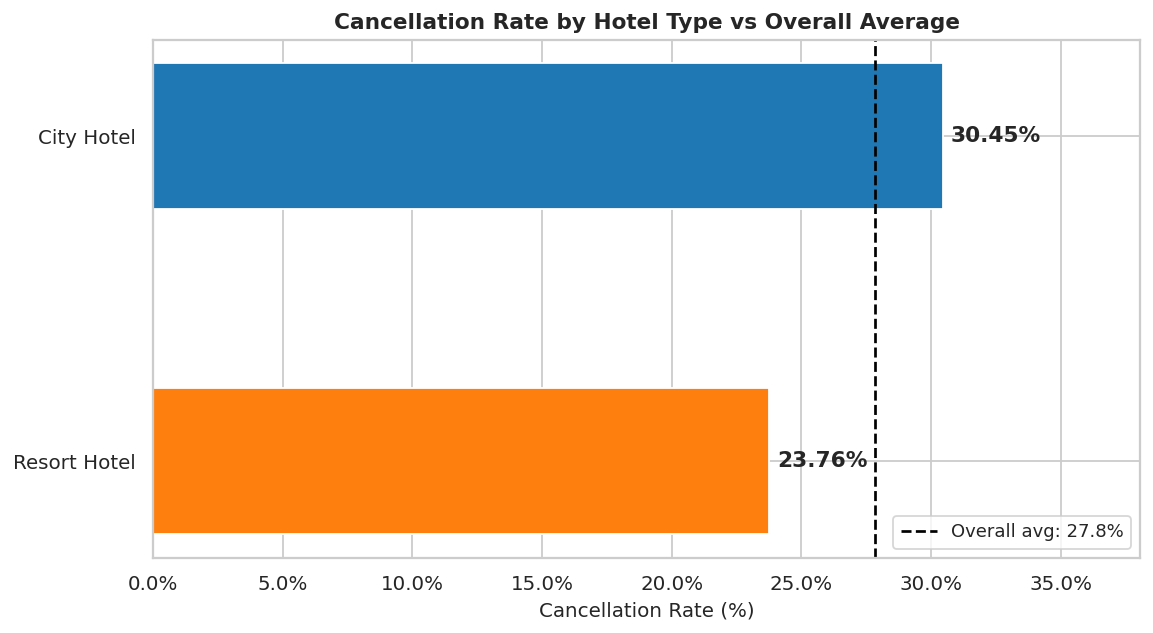

Saved → visuals/cancellation_rate_comparison.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

rate_data = hotel_stats["Cancellation_Rate"].reset_index()
bars = ax.barh(rate_data["hotel"], rate_data["Cancellation_Rate"],
               color=bar_colors, edgecolor="white", height=0.45)

ax.axvline(cancel_rate, color="black", linestyle="--", linewidth=1.5,
           label=f"Overall avg: {cancel_rate:.1f}%")

for bar, rate in zip(bars, rate_data["Cancellation_Rate"]):
    ax.text(bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{rate:.2f}%", va="center", fontsize=12, fontweight="bold")

ax.set_xlabel("Cancellation Rate (%)", fontsize=11)
ax.set_title("Cancellation Rate by Hotel Type vs Overall Average",
             fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(0, max(rate_data["Cancellation_Rate"]) * 1.25)
ax.legend(fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../visuals/cancellation_rate_comparison.png",
            dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved → visuals/cancellation_rate_comparison.png")


---
## 4 — Key Findings & Business Implications

### 4.1 Overall Cancellation Rate

The overall cancellation rate across both hotels is **27.85%** — meaning more than
1 in 4 bookings is cancelled before arrival. With 23,839 cancellations out of 85,598
bookings, this represents a substantial and recurring revenue risk for both properties.

---

### 4.2 Which Hotel Type Has Higher Cancellations?

| Hotel Type | Total Bookings | Cancelled | Cancellation Rate | vs Overall |
|------------|---------------|-----------|------------------|------------|
| **City Hotel** | 52,351 | 15,939 | **30.45%** | +2.60 pp |
| Resort Hotel | 33,247 | 7,900 | **23.76%** | −4.09 pp |

**City Hotel has a significantly higher cancellation rate at 30.45%**, compared to
23.76% for Resort Hotel — a gap of **6.69 percentage points**.

City Hotel also handles a far larger volume of bookings (52,351 vs 33,247), meaning
the absolute number of cancellations is more than double that of Resort Hotel
(15,939 vs 7,900).

---

### 4.3 Why Does City Hotel Cancel More?

Several structural factors likely drive this disparity:

**1. Booking intent & flexibility**
City Hotel guests are more likely to be business travellers or short-break tourists
who book opportunistically and change plans more readily. Resort Hotel guests typically
plan holidays months in advance with stronger commitment to travel.

**2. Lead time & advance bookings**
City Hotel bookings tend to have shorter lead times but also higher last-minute
cancellations. Guests may book multiple city hotels and cancel after confirming
alternatives — a pattern less common for resort stays.

**3. OTA dependency**
City Hotels are more heavily distributed through Online Travel Agents (OTAs like
Booking.com, Expedia), which offer free or flexible cancellation policies as a
competitive differentiator, structurally increasing cancellation risk.

**4. Length of stay**
Resort bookings typically involve longer stays (higher sunk cost of planning),
creating a natural deterrent to cancellation. City stays are often 1–2 nights,
where re-booking friction is low.

---

### 4.4 Business Implications

#### For City Hotel (30.45% cancellation rate) 🔴 High Priority
- **Overbooking strategy:** At a 30% cancellation rate, maintaining a calibrated
  overbooking buffer of 8–12% can recover significant revenue without risking
  too many walk-ins.
- **Deposit policy:** Introduce non-refundable or partially refundable rates for
  high-lead-time bookings to incentivise commitment.
- **Cancellation prediction model:** City Hotel data should be the primary focus
  for the ML model in Week 3 — the signal is stronger and the revenue impact larger.
- **Last-minute promotions:** Use predicted cancellation slots to launch dynamic
  discount campaigns 24–48 hours before arrival.

#### For Resort Hotel (23.76% cancellation rate) 🟡 Moderate
- **Lower urgency** but still meaningful — 1 in 4 resort bookings cancels.
- **Seasonal exposure:** Resort cancellations likely spike during peak summer
  season (July–August). A targeted retention campaign before high-season
  cut-off dates could recover high-value long-stay bookings.
- **Package incentives:** Offer F&B or activity bundles for guests who confirm
  non-refundable rates, converting flexible to committed bookings.

#### Shared priority
- **Revenue at risk (estimate):** With a mean `revenue_per_booking` of ~£403 and
  23,839 cancellations, the theoretical revenue exposure is approximately
  **£9.6 million** across the dataset period — though not all would have been
  recoverable.
- A **1 percentage point reduction** in cancellation rate would retain ~856 bookings
  ≈ **£345,000** in potential revenue.

---

> **Next analysis:** `04_eda_pricing.ipynb` — ADR trends, seasonality, and pricing
> patterns by hotel type, market segment, and arrival month.
